# 22 — Activity Stratification × CGM/HbA1c + Education Gap Audit

**Purpose**: Two related analyses batched together:
1. **Education gap audit** (Section 1): NB13 found dml_gap_education correlates with HbA1c at rho=−0.199 across the full cohort (n=2,182), but Healthy participants arguably should not be included because diabetes education is only relevant to people with or at risk of diabetes. This section re-runs the analysis with and without Healthy to check whether their inclusion distorts the finding.
2. **Activity stratification** (Sections 2–4): Test whether wearable-measured physical activity (Garmin) predicts CGM outcomes and HbA1c across and within study groups. Per-day activity JSON files are used for granular per-person median/SD computation in addition to manifest averages.

**Inputs**:
- Google Drive: `features_with_cluster.csv`, `13_hba1c_per_person.csv`
- Azure: `wearable_activity_monitor` manifest TSV + per-person JSON activity files

**Outputs**: `21_education_gap_audit.csv`, `21_activity_stratification_summary.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, json, getpass, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))

STUDY_ID       = '00b62456-0b93-4975-a992-42ba6a50ed5c'
CONTAINER_NAME = 'aireadi-raw'

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive

def mount_drive():
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        print('Initial mount failed — retrying with force_remount=True...')
        drive.mount('/content/drive', force_remount=True)

mount_drive()
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [14]:
# ── 3. Azure Connection ────────────────────────────────────────────
from azure.storage.blob import BlobServiceClient

IN_COLAB = os.path.exists('/content')
if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted:')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Azure connection established.')

Paste your Azure CONNECTION_STRING when prompted:
Azure connection established.


In [15]:
# ── 4. Load Feature & HbA1c Files from Google Drive ───────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
hba1c_df = pd.read_csv(out_dir / '13_hba1c_per_person.csv')

features['person_id'] = features['person_id'].astype(str)
hba1c_df['person_id'] = hba1c_df['person_id'].astype(str)

if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

df = features.merge(hba1c_df[['person_id', 'hba1c']], on='person_id', how='inner')
df = df.dropna(subset=['hba1c'])
print(f'features: {features.shape}   merged with HbA1c: {df.shape}')
print(df['study_group_label'].value_counts().sort_index().to_string())

features: (2245, 22)   merged with HbA1c: (2182, 23)
study_group_label
Healthy     748
Pre-DM      539
Oral Med    654
Insulin     241


## Section 1: Education Gap Audit

NB13 reported `dml_gap_education` ↔ HbA1c: Spearman rho=−0.199, p<0.0001 across n=2,182.
The question: Healthy participants don't manage diabetes, so their education gap scores may not be meaningful in this context — does including them inflate the apparent correlation?

In [16]:
# ── 1a. Education gap vs HbA1c: full cohort vs diabetes-only ──────
EDU_COL = 'dml_gap_education'

if EDU_COL not in df.columns:
    print(f'WARNING: {EDU_COL} not found in features_with_cluster.csv')
else:
    audit_rows = []

    subsets = [
        ('Full cohort (all 4 groups)', df),
        ('Diabetes groups only (Pre-DM + Oral Med + Insulin)',
         df[df['study_group_label'].isin(['Pre-DM', 'Oral Med', 'Insulin'])]),
        ('Oral Med + Insulin only',
         df[df['study_group_label'].isin(['Oral Med', 'Insulin'])]),
    ] + [(grp, df[df['study_group_label'] == grp]) for grp in STUDY_GROUP_ORDER]

    print(f'=== dml_gap_education vs HbA1c (Spearman) ===\n')
    print(f'{"Subset":<50}  {"rho":>8}  {"p":>12}  {"n":>6}  sig')
    print('-' * 84)

    for label, sub in subsets:
        sub_clean = sub[[EDU_COL, 'hba1c']].dropna()
        if len(sub_clean) < 10:
            continue
        rho, p = stats.spearmanr(sub_clean[EDU_COL], sub_clean['hba1c'])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{label:<50}  {rho:+8.4f}  {p:12.4e}  {len(sub_clean):6d}  {sig}')
        audit_rows.append({'subset': label, 'rho': round(rho, 4), 'p': round(p, 6),
                           'n': len(sub_clean), 'sig': sig})

    audit_df = pd.DataFrame(audit_rows)

=== dml_gap_education vs HbA1c (Spearman) ===

Subset                                                   rho             p       n  sig
------------------------------------------------------------------------------------
Full cohort (all 4 groups)                           -0.1992    5.6522e-21    2182  ***
Diabetes groups only (Pre-DM + Oral Med + Insulin)   -0.0551    3.7059e-02    1434  *
Oral Med + Insulin only                              +0.0230    4.9288e-01     895  ns
Healthy                                              -0.0978    7.4579e-03     748  **
Pre-DM                                               -0.0567    1.8907e-01     539  ns
Oral Med                                             +0.0654    9.4866e-02     654  ns
Insulin                                              -0.0330    6.1023e-01     241  ns


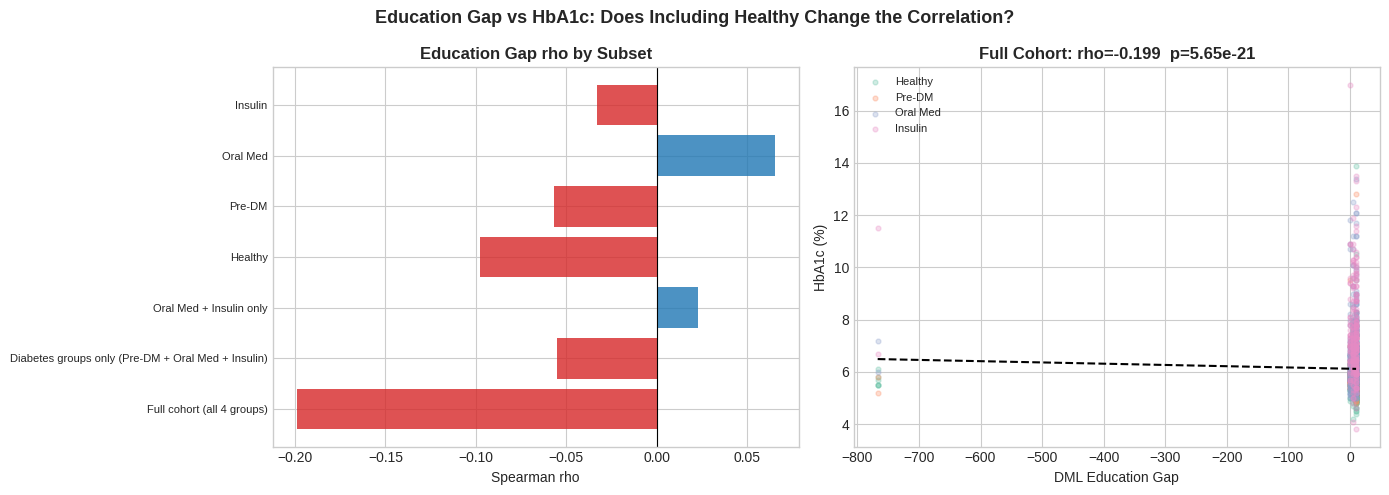

In [17]:
# ── 1b. Visualize: bar chart of rho values by subset ──────────────
if EDU_COL in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Education Gap vs HbA1c: Does Including Healthy Change the Correlation?',
                 fontsize=13, fontweight='bold')

    # Left: bar chart of rho by subset
    bar_data = audit_df[audit_df['subset'].isin([
        'Full cohort (all 4 groups)',
        'Diabetes groups only (Pre-DM + Oral Med + Insulin)',
        'Oral Med + Insulin only',
    ] + STUDY_GROUP_ORDER)]
    bar_colors = ['#d62728' if v < 0 else '#1f77b4' for v in bar_data['rho']]
    axes[0].barh(bar_data['subset'], bar_data['rho'], color=bar_colors, alpha=0.8)
    axes[0].axvline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel('Spearman rho')
    axes[0].set_title('Education Gap rho by Subset', fontweight='bold')
    axes[0].tick_params(axis='y', labelsize=8)

    # Right: scatter for full cohort colored by study group
    sub_scatter = df[[EDU_COL, 'hba1c', 'study_group_label']].dropna()
    for grp in STUDY_GROUP_ORDER:
        s = sub_scatter[sub_scatter['study_group_label'] == grp]
        axes[1].scatter(s[EDU_COL], s['hba1c'],
                        alpha=0.3, s=12, color=STUDY_GROUP_PAL[grp], label=grp)
    m, b, *_ = stats.linregress(sub_scatter[EDU_COL], sub_scatter['hba1c'])
    xs = np.linspace(sub_scatter[EDU_COL].min(), sub_scatter[EDU_COL].max(), 100)
    axes[1].plot(xs, m*xs + b, color='black', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('DML Education Gap')
    axes[1].set_ylabel('HbA1c (%)')
    rho_all, p_all = stats.spearmanr(sub_scatter[EDU_COL], sub_scatter['hba1c'])
    axes[1].set_title(f'Full Cohort: rho={rho_all:.3f}  p={p_all:.2e}', fontweight='bold')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [18]:
# ── 1c. Export education gap audit ────────────────────────────────
if EDU_COL in df.columns:
    audit_df.to_csv(out_dir / '21_education_gap_audit.csv', index=False)
    print('Saved 21_education_gap_audit.csv')
    print(audit_df.to_string(index=False))

Saved 21_education_gap_audit.csv
                                            subset    rho     p    n sig
                        Full cohort (all 4 groups) -0.199 0.000 2182 ***
Diabetes groups only (Pre-DM + Oral Med + Insulin) -0.055 0.037 1434   *
                           Oral Med + Insulin only  0.023 0.493  895  ns
                                           Healthy -0.098 0.007  748  **
                                            Pre-DM -0.057 0.189  539  ns
                                          Oral Med  0.065 0.095  654  ns
                                           Insulin -0.033 0.610  241  ns


## Section 2: Activity Data Engineering

Load per-person activity data two ways:
1. **Manifest averages** (fast): already-computed `average_daily_activity`, `average_active_calories_kcal`
2. **Per-day JSON** (granular): load individual Garmin JSON files to compute per-person median + SD of daily activity

The manifest covers 2,184 participants; JSON files are at
`{STUDY_ID}/dataset/wearable_activity_monitor/{person_id}/physical_activity/{person_id}_ACT.json`

In [19]:
# ── 2a. Load wearable activity manifest ───────────────────────────
print('Loading wearable activity manifest from Azure...')
activity_manifest = load_blob_csv(
    f'{STUDY_ID}/dataset/wearable_activity_monitor/manifest.tsv', sep='\t')
activity_manifest['person_id'] = activity_manifest['person_id'].astype(str)

print(f'Activity manifest: {len(activity_manifest):,} participants')
print('Columns:', activity_manifest.columns.tolist())

# Key columns
ACT_COLS = ['average_daily_activity', 'average_active_calories_kcal',
            'average_heartrate_bpm', 'average_oxygen_saturation_pct',
            'average_stress_level', 'average_respiratory_rate_bpm',
            'average_sleep_hours']
present_act_cols = [c for c in ACT_COLS if c in activity_manifest.columns]
print(f'\nActivity metrics available: {present_act_cols}')
print(activity_manifest[present_act_cols].describe().round(2))

Loading wearable activity manifest from Azure...
Activity manifest: 2,184 participants
Columns: ['person_id', 'wrist_worn_on', 'dominant_hand', 'heartrate_filepath', 'heartrate_record_count', 'average_heartrate_bpm', 'oxygen_saturation_filepath', 'oxygen_saturation_record_count', 'average_oxygen_saturation_pct', 'stress_level_filepath', 'stress_level_record_count', 'average_stress_level', 'sleep_filepath', 'sleep_record_count', 'average_sleep_hours', 'respiratory_rate_filepath', 'respiratory_rate_record_count', 'average_respiratory_rate_bpm', 'physical_activity_filepath', 'physical_activity_num_days', 'average_daily_activity', 'active_calories_filepath', 'active_calories_record_count', 'average_active_calories_kcal', 'sensor_sampling_duration_days', 'manufacturer', 'manufacturer_model_name']

Activity metrics available: ['average_daily_activity', 'average_active_calories_kcal', 'average_heartrate_bpm', 'average_oxygen_saturation_pct', 'average_stress_level', 'average_respiratory_rate_b

In [20]:
# ── 2b. Per-day JSON: load a sample to understand structure ────────
# Manifest filepaths are relative: /wearable_activity_monitor/...
# Full Azure path = {STUDY_ID}/dataset{manifest_filepath}

act_col = 'physical_activity_filepath'
print(f'Physical activity filepath column: {act_col}')

sample_row = activity_manifest[act_col].dropna().iloc[0]
sample_path = f'{STUDY_ID}/dataset{sample_row}'
print(f'Sample path: {sample_path}')

try:
    bc   = container.get_blob_client(sample_path)
    raw  = json.loads(bc.download_blob().readall())
    print(f'Top-level keys: {list(raw.keys())}')
    body = raw.get('body', {})
    print(f'Body keys: {list(body.keys())}')
    activity_list = body.get('activity', [])
    print(f'Activity records: {len(activity_list)}')
    if activity_list:
        non_empty = [r for r in activity_list if r.get('base_movement_quantity', {}).get('value', '') != '']
        print(f'Non-empty step records: {len(non_empty)}')
        print(f'First non-empty record: {non_empty[0] if non_empty else activity_list[0]}')
except Exception as e:
    print(f'Error loading sample: {e}')

Physical activity filepath column: physical_activity_filepath
Sample path: 00b62456-0b93-4975-a992-42ba6a50ed5c/dataset/wearable_activity_monitor/physical_activity/garmin_vivosmart5/1023/1023_activity.json
Top-level keys: ['header', 'body']
Body keys: ['activity']
Activity records: 5524
Non-empty step records: 5522
First non-empty record: {'activity_name': 'sedentary', 'base_movement_quantity': {'value': 0, 'unit': 'steps'}, 'effective_time_frame': {'time_interval': {'start_date_time': '2023-08-30T16:09:50Z', 'end_date_time': '2023-08-30T16:11:50Z'}}}


In [21]:
# ── 2c. Per-day JSON: batch load for all participants ──────────────
# Paths in manifest are relative (e.g. /wearable_activity_monitor/...)
# Full Azure path = {STUDY_ID}/dataset{manifest_filepath}

def extract_daily_activity(person_id):
    """Load one participant's activity JSON and return daily step/calorie summary."""
    try:
        row = activity_manifest[activity_manifest['person_id'] == str(person_id)]
        if row.empty:
            return None

        result = {'person_id': str(person_id)}

        # ── Steps from physical_activity_filepath ──
        act_filepath_col = 'physical_activity_filepath'
        if act_filepath_col in row.columns and pd.notna(row.iloc[0][act_filepath_col]):
            rel_path = row.iloc[0][act_filepath_col]  # starts with /wearable_activity_monitor/...
            full_path = f'{STUDY_ID}/dataset{rel_path}'
            bc = container.get_blob_client(full_path)
            raw = json.loads(bc.download_blob().readall())

            # Schema: {"header": {...}, "body": {"activity": [...]}}
            activity_records = raw.get('body', {}).get('activity', [])

            if activity_records:
                rows = []
                for rec in activity_records:
                    val = rec.get('base_movement_quantity', {}).get('value', '')
                    if val == '' or val is None:
                        continue
                    # Extract date from start_date_time
                    dt = rec.get('effective_time_frame', {}).get('time_interval', {}).get('start_date_time', '')
                    date = dt[:10] if dt else None
                    rows.append({'date': date, 'steps': float(val)})

                if rows:
                    step_df = pd.DataFrame(rows).dropna(subset=['date'])
                    # Sum steps per day, then compute per-person stats
                    daily_steps = step_df.groupby('date')['steps'].sum()
                    result['n_days'] = len(daily_steps)
                    result['daily_steps_median'] = daily_steps.median()
                    result['daily_steps_mean']   = daily_steps.mean()
                    result['daily_steps_sd']     = daily_steps.std()

        # ── Calories from active_calories_filepath ──
        cal_filepath_col = 'active_calories_filepath'
        if cal_filepath_col in row.columns and pd.notna(row.iloc[0][cal_filepath_col]):
            rel_path = row.iloc[0][cal_filepath_col]
            full_path = f'{STUDY_ID}/dataset{rel_path}'
            bc = container.get_blob_client(full_path)
            raw = json.loads(bc.download_blob().readall())

            cal_records = raw.get('body', {}).get('activity', [])
            if cal_records:
                cal_rows = []
                for rec in cal_records:
                    val = rec.get('calories_value', {}).get('value', '')
                    if val == '' or val is None:
                        continue
                    dt = rec.get('effective_time_frame', {}).get('date_time', '')
                    date = dt[:10] if dt else None
                    cal_rows.append({'date': date, 'calories': float(val)})

                if cal_rows:
                    cal_df = pd.DataFrame(cal_rows).dropna(subset=['date'])
                    daily_cal = cal_df.groupby('date')['calories'].sum()
                    result['daily_calories_median'] = daily_cal.median()
                    result['daily_calories_mean']   = daily_cal.mean()

        return result if len(result) > 1 else None

    except Exception as e:
        return None


print('Batch loading per-day activity JSON files...')
print('(This may take 10–20 minutes depending on Colab network speed)')

json_results = []
pids = activity_manifest['person_id'].tolist()
n_total = len(pids)

for i, pid in enumerate(pids):
    res = extract_daily_activity(pid)
    if res:
        json_results.append(res)
    if (i + 1) % 100 == 0:
        print(f'  Loaded {i+1}/{n_total} ({len(json_results)} successful)')

json_df = pd.DataFrame(json_results) if json_results else pd.DataFrame()
print(f'\nPer-day activity loaded: {len(json_df):,} participants')
if not json_df.empty:
    print(json_df.describe().round(2))

Batch loading per-day activity JSON files...
(This may take 10–20 minutes depending on Colab network speed)
  Loaded 100/2184 (100 successful)
  Loaded 200/2184 (199 successful)
  Loaded 300/2184 (299 successful)
  Loaded 400/2184 (396 successful)
  Loaded 500/2184 (492 successful)
  Loaded 600/2184 (591 successful)
  Loaded 700/2184 (690 successful)
  Loaded 800/2184 (789 successful)
  Loaded 900/2184 (889 successful)
  Loaded 1000/2184 (975 successful)
  Loaded 1100/2184 (1069 successful)
  Loaded 1200/2184 (1159 successful)
  Loaded 1300/2184 (1246 successful)
  Loaded 1400/2184 (1336 successful)
  Loaded 1500/2184 (1436 successful)
  Loaded 1600/2184 (1536 successful)
  Loaded 1700/2184 (1636 successful)
  Loaded 1800/2184 (1736 successful)
  Loaded 1900/2184 (1833 successful)
  Loaded 2000/2184 (1932 successful)
  Loaded 2100/2184 (2032 successful)

Per-day activity loaded: 2,116 participants
        n_days  daily_steps_median  daily_steps_mean  daily_steps_sd  \
count 2116.000   

In [22]:
# ── 2d. Merge activity into main dataset ──────────────────────────
act_slim = activity_manifest[['person_id'] + present_act_cols].copy()

# Merge manifest averages
df2 = df.merge(act_slim, on='person_id', how='left')

# Merge per-day JSON metrics (if loaded)
if len(json_df) > 0:
    json_df['person_id'] = json_df['person_id'].astype(str)
    df2 = df2.merge(json_df.drop(columns=['n_days'], errors='ignore'),
                    on='person_id', how='left')

print(f'Merged dataset: {df2.shape}')
print(f'Activity coverage: {df2["average_daily_activity"].notna().sum():,} / {len(df2):,}')

# Primary activity metric for stratification
ACT_PRIMARY = 'average_daily_activity'
df2 = df2.dropna(subset=[ACT_PRIMARY]).copy()
df2['activity_quartile'] = pd.qcut(
    df2[ACT_PRIMARY], q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

print(f'\nActivity quartile distribution:')
print(df2['activity_quartile'].value_counts().sort_index().to_string())

Merged dataset: (2182, 35)
Activity coverage: 2,063 / 2,182

Activity quartile distribution:
activity_quartile
Q1 (Lowest)     516
Q2              516
Q3              515
Q4 (Highest)    516


## Section 3: Activity Quartile Stratification × CGM + HbA1c

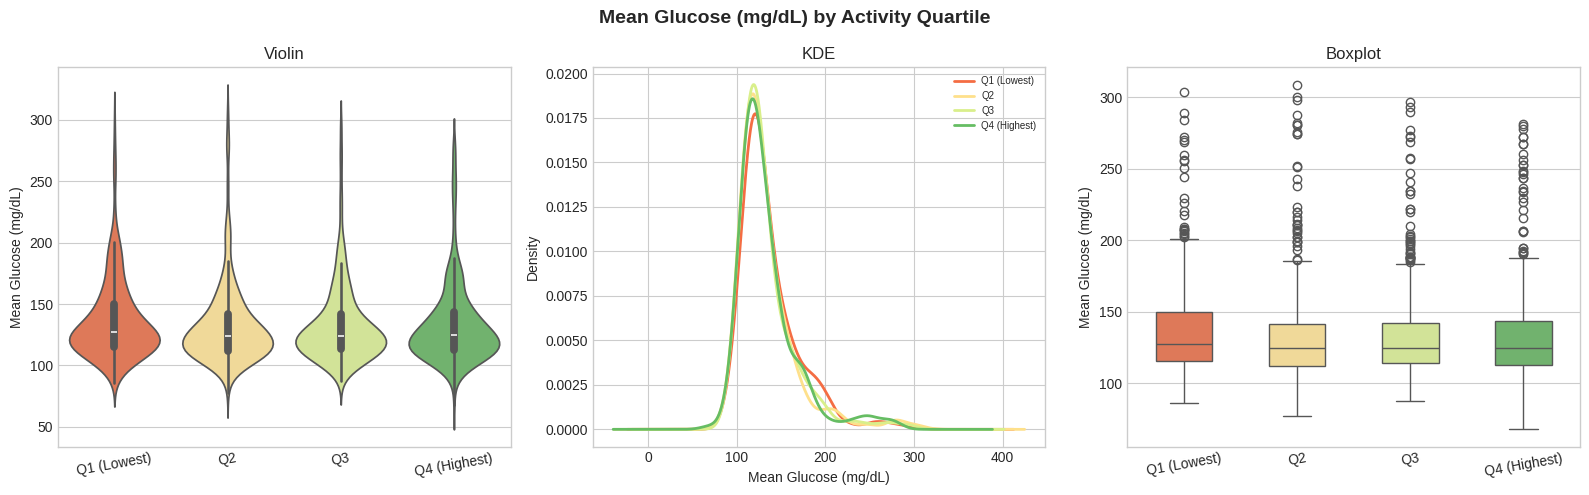

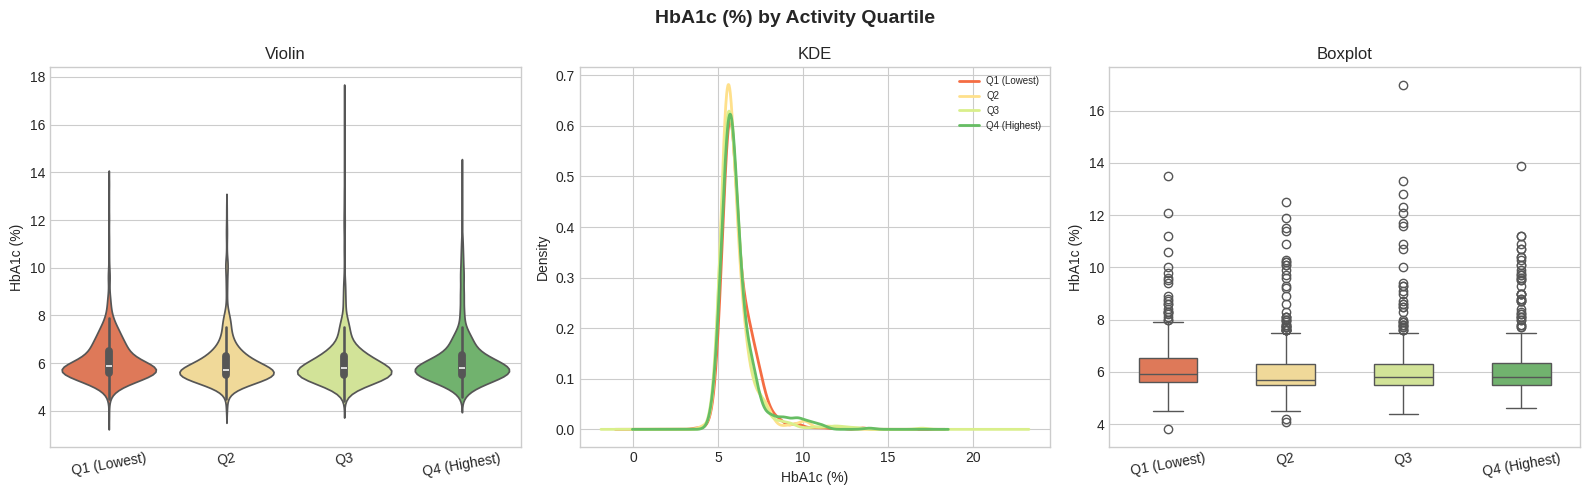

In [23]:
# ── 3a. Distributions: mean_glucose and HbA1c by activity quartile ─
ACT_ORDER = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
ACT_PAL   = dict(zip(ACT_ORDER, sns.color_palette('RdYlGn', 4)))

for outcome, ylabel in [('mean_glucose', 'Mean Glucose (mg/dL)'), ('hba1c', 'HbA1c (%)')]:
    sub = df2.dropna(subset=[outcome, 'activity_quartile'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{ylabel} by Activity Quartile', fontsize=14, fontweight='bold')

    sns.violinplot(data=sub, x='activity_quartile', y=outcome,
                   order=ACT_ORDER, palette=ACT_PAL, inner='box', ax=axes[0])
    axes[0].set_title('Violin'); axes[0].set_xlabel(''); axes[0].set_ylabel(ylabel)
    axes[0].tick_params(axis='x', rotation=10)

    for q in ACT_ORDER:
        sub[sub['activity_quartile'] == q][outcome].plot.kde(
            ax=axes[1], label=q, linewidth=2, color=ACT_PAL[q])
    axes[1].set_title('KDE'); axes[1].set_xlabel(ylabel); axes[1].legend(fontsize=7)

    sns.boxplot(data=sub, x='activity_quartile', y=outcome,
                order=ACT_ORDER, palette=ACT_PAL, width=0.5, ax=axes[2])
    axes[2].set_title('Boxplot'); axes[2].set_xlabel(''); axes[2].set_ylabel(ylabel)
    axes[2].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.show()

In [24]:
# ── 3b. Kruskal-Wallis + pairwise Mann-Whitney: activity × outcomes ─
OUTCOMES = ['mean_glucose', 'hba1c', 'tir', 'tar_180', 'glucose_cv']
available_outcomes = [c for c in OUTCOMES if c in df2.columns]

print('=== Activity Quartile vs Glycemic Outcomes ===\n')
for outcome in available_outcomes:
    sub  = df2.dropna(subset=[outcome, 'activity_quartile'])
    grps = [sub[sub['activity_quartile'] == q][outcome].values for q in ACT_ORDER]
    grps = [g for g in grps if len(g) > 5]
    if len(grps) < 2:
        continue
    H, p_kw = stats.kruskal(*grps)
    rho, p_sp = stats.spearmanr(sub[ACT_PRIMARY], sub[outcome])
    print(f'{outcome}: KW H={H:.2f} p={p_kw:.4e}  Spearman rho={rho:+.3f} p={p_sp:.4e}')

print('\n=== Pairwise Mann-Whitney: Q1 vs Q4 (highest vs lowest activity) ===')
BONF_ALPHA = 0.05 / len(available_outcomes)
print(f'Bonferroni alpha = {BONF_ALPHA:.4f}  ({len(available_outcomes)} outcomes)\n')

for outcome in available_outcomes:
    sub = df2.dropna(subset=[outcome, 'activity_quartile'])
    q1  = sub[sub['activity_quartile'] == 'Q1 (Lowest)'][outcome]
    q4  = sub[sub['activity_quartile'] == 'Q4 (Highest)'][outcome]
    if len(q1) < 5 or len(q4) < 5:
        continue
    u, p = stats.mannwhitneyu(q1, q4, alternative='two-sided')
    d    = (q4.mean() - q1.mean()) / np.sqrt((q1.std(ddof=1)**2 + q4.std(ddof=1)**2) / 2)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{outcome:20s}  Q1={q1.mean():.2f}  Q4={q4.mean():.2f}  diff={q4.mean()-q1.mean():+.2f}  '
          f'd={d:+.3f}  p={p:.4f}  {sig}')

=== Activity Quartile vs Glycemic Outcomes ===

mean_glucose: KW H=8.88 p=3.0862e-02  Spearman rho=-0.050 p=2.2222e-02
hba1c: KW H=17.99 p=4.4101e-04  Spearman rho=-0.024 p=2.7450e-01

=== Pairwise Mann-Whitney: Q1 vs Q4 (highest vs lowest activity) ===
Bonferroni alpha = 0.0250  (2 outcomes)

mean_glucose          Q1=137.14  Q4=133.98  diff=-3.16  d=-0.094  p=0.0223  *
hba1c                 Q1=6.17  Q4=6.16  diff=-0.00  d=-0.001  p=0.1664  ns


In [25]:
# ── 3c. Within-study-group: activity vs mean_glucose and HbA1c ────
print('=== Within-Group Spearman: Activity vs Glycemic Outcomes ===\n')
print(f'{"Study Group":<12}  {"Outcome":<15}  {"rho":>8}  {"p":>12}  {"n":>6}  sig')
print('-' * 65)

for grp in STUDY_GROUP_ORDER:
    sub_grp = df2[df2['study_group_label'] == grp]
    for outcome in available_outcomes:
        sub = sub_grp[[ACT_PRIMARY, outcome]].dropna()
        if len(sub) < 20:
            continue
        rho, p = stats.spearmanr(sub[ACT_PRIMARY], sub[outcome])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:<12}  {outcome:<15}  {rho:+8.4f}  {p:12.4e}  {len(sub):6d}  {sig}')

=== Within-Group Spearman: Activity vs Glycemic Outcomes ===

Study Group   Outcome               rho             p       n  sig
-----------------------------------------------------------------
Healthy       mean_glucose      -0.0625    9.6892e-02     707  ns
Healthy       hba1c             +0.0258    4.9294e-01     707  ns
Pre-DM        mean_glucose      -0.0703    1.1114e-01     515  ns
Pre-DM        hba1c             -0.0654    1.3840e-01     515  ns
Oral Med      mean_glucose      -0.0198    6.2555e-01     611  ns
Oral Med      hba1c             +0.0149    7.1372e-01     611  ns
Insulin       mean_glucose      +0.0134    8.4013e-01     230  ns
Insulin       hba1c             +0.0103    8.7673e-01     230  ns


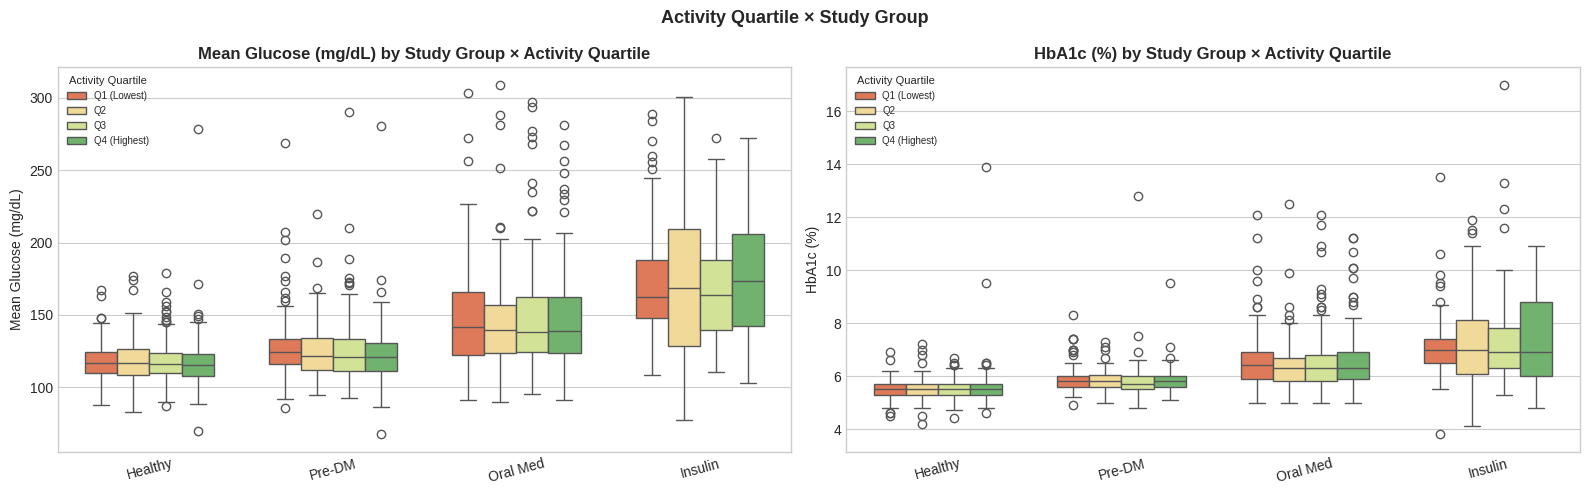

In [26]:
# ── 3d. Interaction boxplot: activity quartile × study group ──────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Activity Quartile × Study Group', fontsize=13, fontweight='bold')

for ax, outcome, ylabel in zip(axes,
                                ['mean_glucose', 'hba1c'],
                                ['Mean Glucose (mg/dL)', 'HbA1c (%)']):
    sub = df2.dropna(subset=[outcome, 'activity_quartile', 'study_group_label'])
    sns.boxplot(data=sub, x='study_group_label', y=outcome,
                hue='activity_quartile',
                order=STUDY_GROUP_ORDER, hue_order=ACT_ORDER,
                palette='RdYlGn', width=0.7, ax=ax)
    ax.set_title(f'{ylabel} by Study Group × Activity Quartile', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.legend(title='Activity Quartile', fontsize=7, title_fontsize=8)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Section 4: Activity vs Other Wearable Metrics

In [27]:
# ── 4a. Spearman correlations: activity vs all wearable metrics ────
WEARABLE_METRICS = [
    ('average_heartrate_bpm',        'Avg Heart Rate (bpm)'),
    ('average_stress_level',         'Avg Stress Level'),
    ('average_oxygen_saturation_pct','Avg SpO2 (%)'),
    ('average_respiratory_rate_bpm', 'Avg Respiratory Rate (bpm)'),
    ('average_sleep_hours',          'Avg Sleep (hrs)'),
]

print(f'=== Activity vs Wearable Metrics (Spearman) ===\n')
print(f'{"Metric":<35}  {"rho":>8}  {"p":>12}  {"n":>6}  sig')
print('-' * 70)

wearable_corrs = []
for col, label in WEARABLE_METRICS:
    if col not in df2.columns:
        continue
    sub = df2[[ACT_PRIMARY, col]].dropna()
    if len(sub) < 30:
        continue
    rho, p = stats.spearmanr(sub[ACT_PRIMARY], sub[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label:<35}  {rho:+8.4f}  {p:12.4e}  {len(sub):6d}  {sig}')
    wearable_corrs.append({'metric': col, 'label': label, 'rho': rho, 'p': p, 'n': len(sub)})

=== Activity vs Wearable Metrics (Spearman) ===

Metric                                    rho             p       n  sig
----------------------------------------------------------------------
Avg Heart Rate (bpm)                  +0.7289    0.0000e+00    2026  ***
Avg Stress Level                      +0.5426   4.1082e-156    2034  ***
Avg SpO2 (%)                          +0.0238    3.4388e-01    1580  ns
Avg Respiratory Rate (bpm)            +0.3659    1.6508e-65    2035  ***
Avg Sleep (hrs)                       +0.1509    5.6386e-12    2063  ***


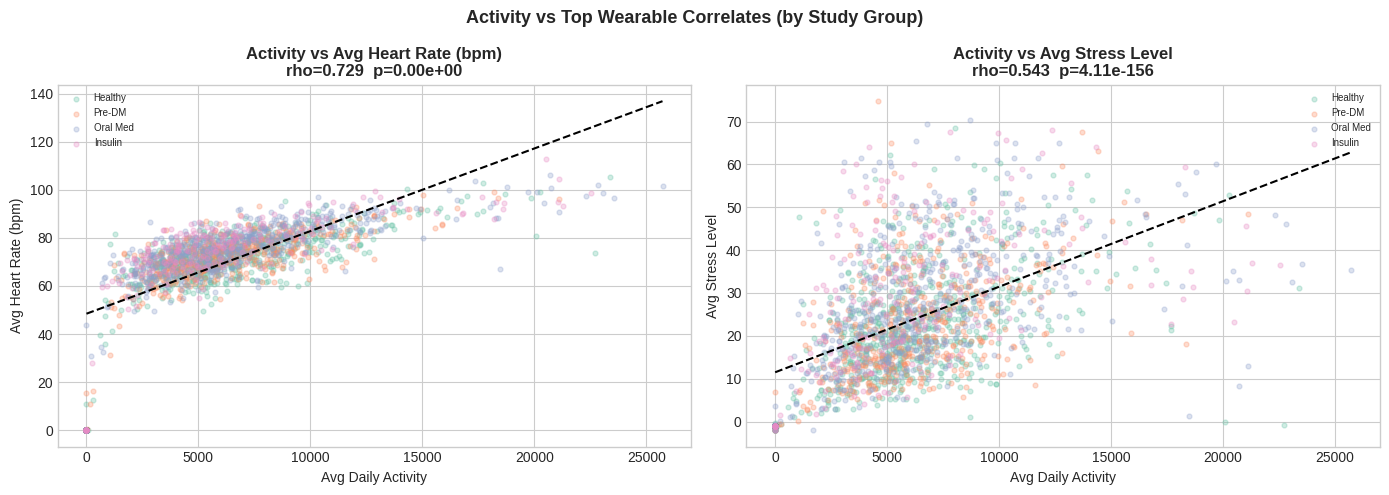

In [28]:
# ── 4b. Scatter: top 2 wearable correlates of activity by study group ─
if wearable_corrs:
    top2 = sorted(wearable_corrs, key=lambda x: abs(x['rho']), reverse=True)[:2]

    fig, axes = plt.subplots(1, len(top2), figsize=(7 * len(top2), 5))
    if len(top2) == 1:
        axes = [axes]
    fig.suptitle('Activity vs Top Wearable Correlates (by Study Group)',
                 fontsize=13, fontweight='bold')

    for ax, item in zip(axes, top2):
        col, label = item['metric'], item['label']
        sub = df2[[ACT_PRIMARY, col, 'study_group_label']].dropna()
        for grp in STUDY_GROUP_ORDER:
            s = sub[sub['study_group_label'] == grp]
            ax.scatter(s[ACT_PRIMARY], s[col], alpha=0.3, s=12,
                       color=STUDY_GROUP_PAL[grp], label=grp)
        m, b, *_ = stats.linregress(sub[ACT_PRIMARY], sub[col])
        xs = np.linspace(sub[ACT_PRIMARY].min(), sub[ACT_PRIMARY].max(), 100)
        ax.plot(xs, m*xs + b, color='black', linewidth=1.5, linestyle='--')
        rho_v, p_v = stats.spearmanr(sub[ACT_PRIMARY], sub[col])
        ax.set_xlabel('Avg Daily Activity')
        ax.set_ylabel(label)
        ax.set_title(f'Activity vs {label}\nrho={rho_v:.3f}  p={p_v:.2e}', fontweight='bold')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

=== Activity by Comorbidity Cluster ===
Cardiometabolic:       mean=5749.6  SD=3804.2  n=843
Musculoskeletal-Infl:  mean=6451.6  SD=3778.2  n=1,220
Mann-Whitney U  p=0.0000  Cohen d=+0.185


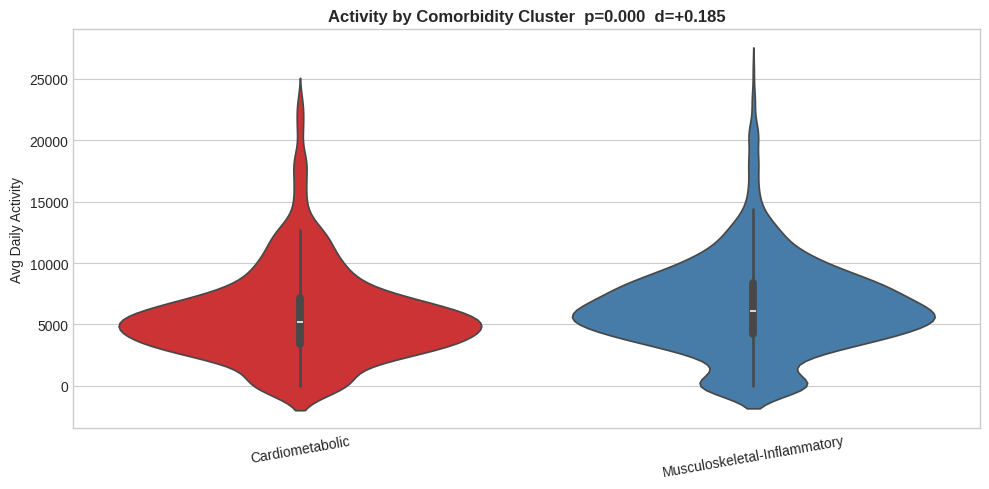

In [29]:
# ── 4c. Activity × comorbidity cluster ────────────────────────────
CLUSTER_MAP   = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}
CLUSTER_ORDER = ['Cardiometabolic', 'Musculoskeletal-Inflammatory']

if 'comorbidity_cluster' in df2.columns:
    df2['cluster_label'] = df2['comorbidity_cluster'].map(CLUSTER_MAP)
    sub = df2.dropna(subset=[ACT_PRIMARY, 'cluster_label'])

    c0 = sub[sub['comorbidity_cluster'] == 0][ACT_PRIMARY]
    c1 = sub[sub['comorbidity_cluster'] == 1][ACT_PRIMARY]
    u, p = stats.mannwhitneyu(c0, c1, alternative='two-sided')
    d   = (c1.mean() - c0.mean()) / np.sqrt((c0.std(ddof=1)**2 + c1.std(ddof=1)**2) / 2)

    print('=== Activity by Comorbidity Cluster ===')
    print(f'Cardiometabolic:       mean={c0.mean():.1f}  SD={c0.std():.1f}  n={len(c0):,}')
    print(f'Musculoskeletal-Infl:  mean={c1.mean():.1f}  SD={c1.std():.1f}  n={len(c1):,}')
    print(f'Mann-Whitney U  p={p:.4f}  Cohen d={d:+.3f}')

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.violinplot(data=sub, x='cluster_label', y=ACT_PRIMARY,
                   order=CLUSTER_ORDER, palette='Set1', inner='box', ax=ax)
    ax.set_title(f'Activity by Comorbidity Cluster  p={p:.3f}  d={d:+.3f}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Avg Daily Activity')
    ax.tick_params(axis='x', rotation=10)
    plt.tight_layout()
    plt.show()

## Summary Table & Export

In [30]:
# ── Summary table + per-person activity export ────────────────────
summary_rows = []
for grp in ['All'] + STUDY_GROUP_ORDER:
    sub = df2 if grp == 'All' else df2[df2['study_group_label'] == grp]
    for q in ['All'] + ACT_ORDER:
        s = sub if q == 'All' else sub[sub['activity_quartile'] == q]
        if len(s) < 5:
            continue
        row = {'study_group': grp, 'activity_quartile': q, 'n': len(s)}
        for outcome in available_outcomes:
            if outcome in s.columns:
                row[f'{outcome}_mean'] = round(s[outcome].mean(), 3)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df[summary_df['activity_quartile'] == 'All'].to_string(index=False))

summary_df.to_csv(out_dir / '21_activity_stratification_summary.csv', index=False)
print('\nSaved 21_activity_stratification_summary.csv')

# ── Per-person activity export (used by NB22 for mediation analysis) ──
# Include manifest averages + per-day JSON metrics for all participants in df2
per_person_act_cols = (
    ['person_id']
    + [c for c in present_act_cols if c in df2.columns]
    + [c for c in ['daily_steps_median', 'daily_steps_mean', 'daily_steps_sd',
                   'daily_calories_median', 'daily_calories_mean'] if c in df2.columns]
)
per_person_act = df2[per_person_act_cols].drop_duplicates('person_id')
per_person_act.to_csv(out_dir / '21_per_person_activity.csv', index=False)
print(f'Saved 21_per_person_activity.csv  ({len(per_person_act):,} participants, '
      f'columns: {per_person_act.columns.tolist()})')

study_group activity_quartile    n  mean_glucose_mean  hba1c_mean
        All               All 2063            134.528       6.109
    Healthy               All  707            117.795       5.528
     Pre-DM               All  515            125.567       5.852
   Oral Med               All  611            146.625       6.524
    Insulin               All  230            173.892       7.366

Saved 21_activity_stratification_summary.csv
Saved 21_per_person_activity.csv  (2,063 participants, columns: ['person_id', 'average_daily_activity', 'average_active_calories_kcal', 'average_heartrate_bpm', 'average_oxygen_saturation_pct', 'average_stress_level', 'average_respiratory_rate_bpm', 'average_sleep_hours', 'daily_steps_median', 'daily_steps_mean', 'daily_steps_sd', 'daily_calories_median', 'daily_calories_mean'])


## Key Findings

### Education Gap Audit (Section 1)

NB13 reported `dml_gap_education` ↔ HbA1c: Spearman rho=−0.199, p<0.0001, n=2,182. **This finding is largely an artifact of including Healthy participants.**

| Subset | rho | p | n | sig |
|--------|-----|---|---|-----|
| Full cohort (all 4 groups) | −0.199 | <0.0001 | 2,182 | *** |
| Diabetes groups only (Pre-DM + Oral Med + Insulin) | −0.055 | 0.037 | 1,434 | * |
| Oral Med + Insulin only | +0.023 | 0.493 | 895 | ns |
| Healthy (isolated) | −0.098 | 0.008 | 748 | ** |
| Pre-DM (isolated) | −0.057 | 0.189 | 539 | ns |
| Oral Med (isolated) | +0.065 | 0.095 | 654 | ns |
| Insulin (isolated) | −0.033 | 0.610 | 241 | ns |

**Interpretation**: The NB13 correlation is driven by the Healthy group. Healthy participants anchor the association because they have uniformly low HbA1c (mean ~5.5%) and relatively higher diabetes education literacy scores — their inclusion creates a spurious between-group gradient that mimics a within-person relationship. Once Healthy participants are excluded, the education gap → HbA1c correlation drops from rho=−0.199 to −0.055 (marginally significant), and within Oral Med or Insulin groups alone the relationship is null (p>0.09). **The NB13 education gap finding should not be interpreted as evidence that diabetes education literacy predicts glycemic control at the individual patient level within disease-relevant populations.**

---

### Activity Data Engineering (Section 2)

- Wearable activity manifest coverage: **2,063 / 2,182 participants** (94.5%)
- Per-day JSON files loaded: **2,116 participants** successfully parsed
- Median daily steps: **5,799** (IQR: 3,212–8,419); mean 6,247 (SD 3,829)
- Activity data format: `{"header": {...}, "body": {"activity": [...]}}` — each record is a time-interval activity segment; steps summed per calendar day before computing per-person statistics

---

### Activity Quartile × Glycemic Outcomes (Section 3)

**Mean glucose:**
- Kruskal-Wallis: H=8.88, p=0.031* — significant distributional difference across quartiles
- Q1 (least active) vs Q4 (most active): 137.14 vs 133.98 mg/dL, diff=−3.16, Cohen's d=−0.094, p=0.022*

**HbA1c:**
- Kruskal-Wallis: H=17.99, p=0.0004*** — distributional difference detected
- Q1 vs Q4: 6.17% vs 6.16%, diff≈0, d=−0.001, p=0.166 ns
- Note: The KW significance reflects distributional shape differences across all four quartiles (not a monotonic mean shift); the Q1 vs Q4 pairwise test shows no meaningful mean difference in HbA1c

**Within-group (Spearman activity vs glycemic outcomes):** All associations non-significant across all four study groups (rho range: −0.070 to +0.013, all p>0.08).

**Interpretation**: Physical activity has a small but statistically detectable cross-sectional association with mean glucose (d=−0.094) but not with HbA1c. Within disease-severity subgroups the signal disappears entirely, indicating that study group (disease severity) is the dominant driver of glycemic outcomes. The cross-sectional activity effect is likely confounded by health status — healthier participants are naturally both more active and have lower glucose.

---

### Activity × Wearable Metrics (Section 4)

| Wearable Metric | rho | sig |
|----------------|-----|-----|
| Avg Heart Rate (bpm) | +0.729 | *** |
| Avg Stress Level | +0.543 | *** |
| Avg Respiratory Rate (bpm) | +0.366 | *** |
| Avg Sleep Hours | +0.151 | *** |
| Avg SpO2 (%) | +0.024 | ns |

Heart rate is by far the strongest wearable correlate of activity (rho=+0.73), which is expected — higher daily step count drives higher average HR captured by the Garmin device. Stress level and respiratory rate also correlate strongly, consistent with physiological co-activation during physical exertion. SpO2 is orthogonal to activity level in this cohort.